# Declaration of Originality

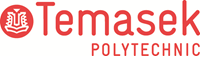

**TEMASEK POLYTECHNIC**
<br>**SCHOOL OF INFORMATICS & IT**
<br>**DIPLOMA IN INFORMATION TECHNOLOGY**
<br>**MACHINE LEARNING FOR DEVELOPERS (CAI2C08)**
<br>**AY2025/2026 OCTOBER SEMESTER**

**PROJECT PROGRAM CODES**
* Student Name (Matric Number)  : Ho Seng Kiat Victor (2400293C)
* Tutorial Group                : PC05 
* Tutor						    : Kian Eng Ong 
* Submission Date               : 


**Declaration of Originality**
* I am the originator of this work and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [97]:
## Import libraries
import pandas as pd
import numpy as np
import plotly 
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import json
import requests

# 1. Business Understanding

## Business Objective
Build a resale price estimation model for HDB resale flats that helps both buyers and sellers make quicker, more informed decisions, which in turn helps our real estate company attract qualified leads through an online price estimation tool.

## Primary Users
- Buyers: want a fair price range before viewing or making an offer.
- Sellers: want a realistic listing price to avoid underpricing or long time on the market.

## Provider
- Real estate company: attract more customers and improve conversion rate.

## Goal
Create a supervised regression model that accurately predicts the resale price of flats based on past transaction data and flat attributes to support buyers/sellers with more informed pricing decisions. The model will focus on the post‑COVID market (2022 onwards), which better reflects a “new normal” after the supply delays and shifting demand faced during the pandemic.

## Strategy
Utilize the resale flat price prediction tool as a free “lead magnet” on our website to attract customers and collect their personal information.

## Scope
- Domain: HDB resale flats in Singapore.
- Time period: 2022 onward (post‑COVID market regime).
- Input features: flat attributes and historical transactions.

## Success Criteria (KPIs)
- Predictive accuracy: low MAE/RMSE on a time‑based holdout set.
- Practical usefulness: estimates fall within a reasonable range for decision‑making.
- Business impact: increased qualified inquiries generated by the tool.

## Assumptions 
- Data from 2022 onward better reflects today’s market.
- Wider economy variables like interest rates or inflation are not taken into account.

## Risks
- Sudden policy or market shifts may reduce model reliability.
- The model does not replace professional valuation or legal advice.


# 2. Data Understanding

## 2.1 Load dataset

In [98]:
## Read *.csv file into pandas DataFrame
FILE_PATH = 'ResaleFlatPrice.csv'
df = pd.read_csv(FILE_PATH)
df


,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
222213,2026-01,YISHUN,4 ROOM,334B,YISHUN ST 31,04 TO 06,92.0,Model A,2015,88 years 11 months,585000.0
222214,2026-01,YISHUN,4 ROOM,336C,YISHUN ST 31,10 TO 12,92.0,Model A,2015,88 years 11 months,620888.0
222215,2026-01,YISHUN,4 ROOM,479B,YISHUN ST 42,01 TO 03,93.0,Model A,2021,94 years 04 months,575000.0
222216,2026-01,YISHUN,4 ROOM,754,YISHUN ST 72,10 TO 12,84.0,Simplified,1985,58 years 09 months,490000.0


In [99]:
## Convert month to datetime format
df['year'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce').dt.year

## Drop month column
df = df.drop('month', axis=1)

## Filter data for post-covid data from year 2022 onwards
df = df[df['year'] >= 2022]

df


,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year
116676,ANG MO KIO,2 ROOM,323,ANG MO KIO AVE 3,07 TO 09,44.0,Improved,1977,54 years 05 months,245000.0,2022
116677,ANG MO KIO,3 ROOM,560,ANG MO KIO AVE 10,01 TO 03,67.0,New Generation,1980,57 years 02 months,300000.0,2022
116678,ANG MO KIO,3 ROOM,444,ANG MO KIO AVE 10,01 TO 03,67.0,New Generation,1979,56 years 07 months,315000.0,2022
116679,ANG MO KIO,3 ROOM,556,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1980,57 years 01 month,318000.0,2022
116680,ANG MO KIO,3 ROOM,556,ANG MO KIO AVE 10,01 TO 03,68.0,New Generation,1980,57 years,320000.0,2022
...,...,...,...,...,...,...,...,...,...,...,...
222213,YISHUN,4 ROOM,334B,YISHUN ST 31,04 TO 06,92.0,Model A,2015,88 years 11 months,585000.0,2026
222214,YISHUN,4 ROOM,336C,YISHUN ST 31,10 TO 12,92.0,Model A,2015,88 years 11 months,620888.0,2026
222215,YISHUN,4 ROOM,479B,YISHUN ST 42,01 TO 03,93.0,Model A,2021,94 years 04 months,575000.0,2026
222216,YISHUN,4 ROOM,754,YISHUN ST 72,10 TO 12,84.0,Simplified,1985,58 years 09 months,490000.0,2026


## 2.2 Summary Statistics

In [100]:
## Understand the type of variable for each column
df.dtypes

town                    object
flat_type               object
block                   object
street_name             object
storey_range            object
floor_area_sqm         float64
flat_model              object
lease_commence_date      int64
remaining_lease         object
resale_price           float64
year                     int32
dtype: object

In [101]:
## Check for missing data
df.isnull().sum()

town                   0
flat_type              0
block                  0
street_name            0
storey_range           0
floor_area_sqm         0
flat_model             0
lease_commence_date    0
remaining_lease        0
resale_price           0
year                   0
dtype: int64

In [102]:
## Check for duplicates that are exactly the same across all columns
df.duplicated().sum()

## View duplicate rows to ensure they are exact duplicates before dropping.
dupes = df[df.duplicated(keep=False)]
dupes.head()

,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,year
119420,BISHAN,5 ROOM,183,BISHAN ST 13,07 TO 09,121.0,Improved,1987,63 years 08 months,895000.0,2022
119422,BISHAN,5 ROOM,183,BISHAN ST 13,07 TO 09,121.0,Improved,1987,63 years 08 months,895000.0,2022
122615,CHOA CHU KANG,3 ROOM,802C,KEAT HONG CL,04 TO 06,67.0,Model A,2018,95 years 02 months,388000.0,2022
122616,CHOA CHU KANG,3 ROOM,802C,KEAT HONG CL,04 TO 06,67.0,Model A,2018,95 years 02 months,388000.0,2022
122938,CHOA CHU KANG,4 ROOM,803B,KEAT HONG CL,07 TO 09,93.0,Model A,2017,94 years 02 months,520000.0,2022


In [103]:
## Min/max sanity checks for key numeric columns
df[['resale_price','floor_area_sqm','lease_commence_date','year']].agg(['min','max'])


,resale_price,floor_area_sqm,lease_commence_date,year
min,150000.0,31.0,1966,2022
max,1658888.0,366.7,2022,2026


In [104]:
## Unique values in each column
df.nunique()

town                     26
flat_type                 7
block                  2741
street_name             575
storey_range             17
floor_area_sqm          174
flat_model               21
lease_commence_date      57
remaining_lease         676
resale_price           3456
year                      5
dtype: int64

In [105]:
## Summary statistics for numerical columns
df.describe()

,floor_area_sqm,lease_commence_date,resale_price,year
count,105542.000000,105542.000000,1.055420e+05,105542.000000
mean,95.571275,1997.945425,5.962507e+05,2023.489928
std,23.845864,15.067124,1.886045e+05,1.113178
min,31.000000,1966.000000,1.500000e+05,2022.000000
25%,74.000000,1985.000000,4.600000e+05,2022.000000
50%,93.000000,1998.000000,5.700000e+05,2024.000000
75%,112.000000,2015.000000,6.990000e+05,2024.000000
max,366.700000,2022.000000,1.658888e+06,2026.000000


## 2.2 Summary Statistics Insights 

1. Dataset size after filtering:  
After keeping only 2022 onward, the dataset contains 105,542 rows (down from the full 222,218), which focuses the model on the post‑COVID market period.

2. df.dtypes:  
The dataset includes mixed data types. Key numerical features such as `remaining_lease`, `month`, and `storey_range` were stored as objects due to string formats (e.g., `storey_range` = “1 TO 3”), so these require conversion before modeling.

3. df.isnull().sum():  
No missing values were found, indicating good data integrity (expected for an official government dataset).

4. df.nunique():  
Categorical columns with lower cardinality such as `flat_type` (7), `flat_model` (21), and `town` (26) are suitable for encoding. High‑cardinality columns like `street_name` (577) and `block` (2745) would introduce sparsity and were dropped.

5. Duplicates (df.duplicated().sum()):  
A small number of exact duplicate rows (96) were detected and removed to avoid double‑counting. I also assumed the possibility that some duplicates may appear after removing month, since two transactions in different months could become identical. However, this is unlikely because other attributes (including the exact resale price) would also have to be identical, and the MOP restrictions make repeat transactions within a short time span improbable.

6. Numeric sanity checks (min/max):  
Ranges for key numeric fields (`resale_price`, `floor_area_sqm`, `lease_commence_date`, `year`) were checked to confirm values fall within reasonable limits after filtering to 2022 onward.


## 2.3 Data Preprocessing

In [106]:

## Dropping exact duplicates, that are the same exact record, likely due to data entry error.
df = df.drop_duplicates()

## Dropping columns that are pure identifiers and is not useful for analysis of resale price,

df = df.drop(columns = ['block','street_name'], axis=1)

## Perform Custom Encoding on flat_type column
flat_type_map = {
    '1 ROOM': 1,
    '2 ROOM': 2,
    '3 ROOM': 3,
    '4 ROOM': 4,
    '5 ROOM': 5,
    'EXECUTIVE': 6,
    'MULTI-GENERATION': 7
}

df['flat_type_ordinal'] = df['flat_type'].map(flat_type_map)

## Convert storey_range like "10 TO 12" → 11
df['storey_avg'] = (
    df['storey_range']
    .astype(str)
    .str.extract(r'(\d+)\s*TO\s*(\d+)')
    .astype(float)
    .mean(axis=1)
)

## Convert remaining_lease like "78 years 6 months" → 78.5
df['remaining_lease_years'] = (
    df['remaining_lease']
    .astype(str)
    .str.extract(r'(?:(\d+)\s*years?)?\s*(?:(\d+)\s*months?)?')
    .fillna(0)
    .astype(float)
    .apply(lambda x: x[0] + x[1] / 12, axis=1)
)

## DATA TYPE STANDATDIZATION
## Convert floor_area_sqm and lease_commence_date to numeric for EDA plots/correlation
df['floor_area_sqm'] = pd.to_numeric(df['floor_area_sqm'], errors='coerce')
df['lease_commence_date'] = pd.to_numeric(df['lease_commence_date'], errors='coerce')


## Drop original column after conversion
df = df.drop(columns=['remaining_lease','storey_range'], errors='ignore')




**Data Preprocessing Justification:**

1. Checked for exact duplicate rows and removed them to avoid double‑counting. 
2. Dropped high‑cardinality columns `block` and `street_name` because they contain hundreds/thousands of unique values, which would add sparse noise and increase the risk of overfitting.
3. Encoded `flat_type` with an ordinal mapping. While “1 ROOM” to “5 ROOM” follow a clear size progression, “EXECUTIVE” and “MULTI‑GENERATION” are larger in practice, so they were assigned higher values (6, 7) based on domain knowledge of HDB layouts.
4. Converted `storey_range` (e.g., “04 TO 06”) into a numeric feature by taking the mean of the range so the model can capture the relationship between floor height and resale price.
5. Converted `remaining_lease` from mixed text (years + months) into a single numeric value in years to enable regression and correlation analysis.
6. Extracted `year` from `month` to visualize historical price trends during EDA (and optionally use it as a feature if justified later).

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

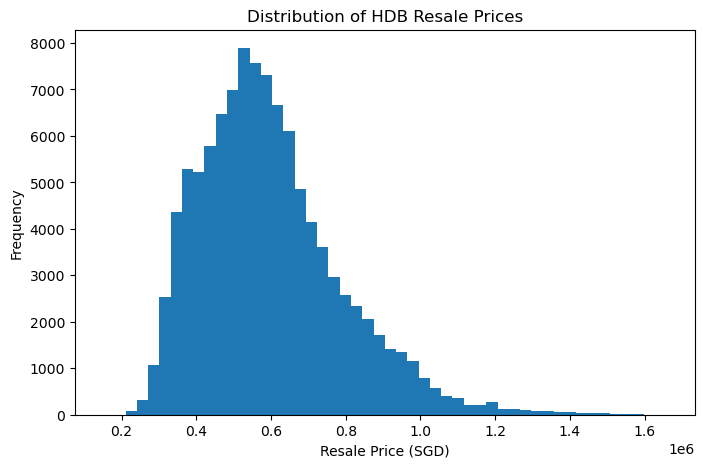

In [107]:
## Understanding distribution of HDB resale prices
plt.figure(figsize=(8,5))
plt.hist(df['resale_price'], bins=50)
plt.xlabel('Resale Price (SGD)')
plt.ylabel('Frequency')
plt.title('Distribution of HDB Resale Prices')
plt.show()


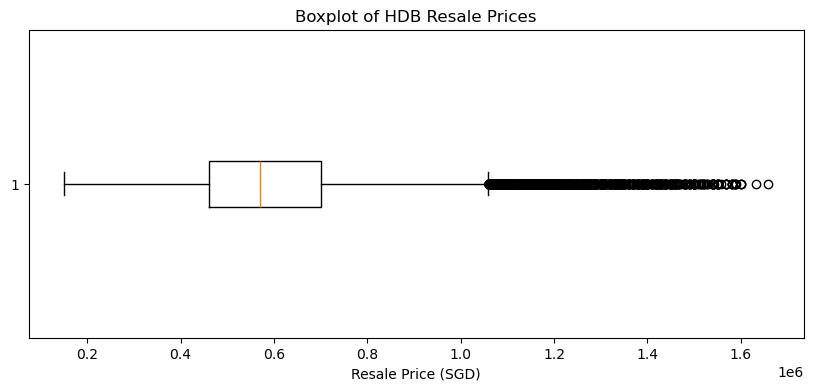

In [108]:
## Boxplot of resale prices to identify outliers
plt.figure(figsize=(10,4))
plt.boxplot(df['resale_price'], vert=False)
plt.xlabel('Resale Price (SGD)')
plt.title('Boxplot of HDB Resale Prices')
plt.show()

In [109]:
## Summary statistics + quantiles for resale prices
df['resale_price'].quantile([0, 0.25, 0.5, 0.75, 1])


0.00     150000.0
0.25     460000.0
0.50     570000.0
0.75     699866.0
1.00    1658888.0
Name: resale_price, dtype: float64

**Understanding distribution of target**

From the histogram, I can tell that the resale_price distribution is right‑skewed, where most transactions fall in the lower‑to‑mid price range and a lower number of flats are sold at very high prices. This explains the long tail on the right side of the graph.

From the boxplot and quantiles, the median resale price is about **$570,000**, and the middle 50% of transactions are roughly between **$460,000 (Q1)** and **$699,000 (Q3)**. The min price is around **$150,000**, while the max goes up to about **$1,658,888**, indicating clear high‑end outliers.


### 2.3.1.2 Understanding distribution of features

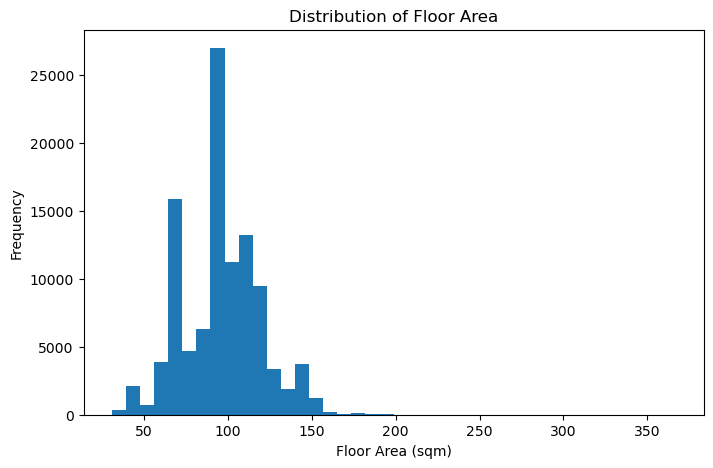

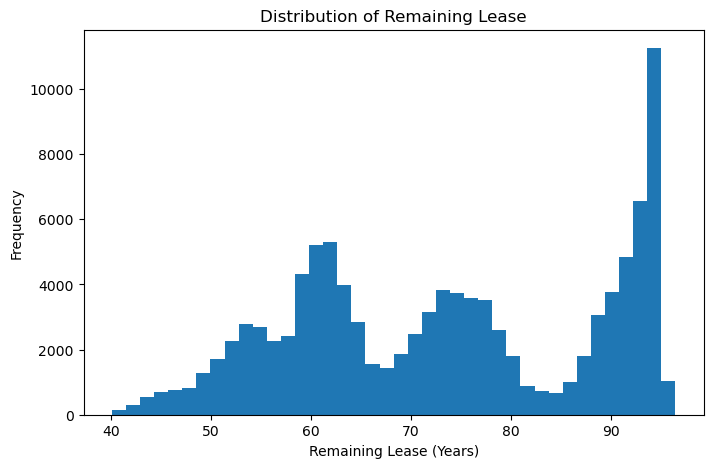

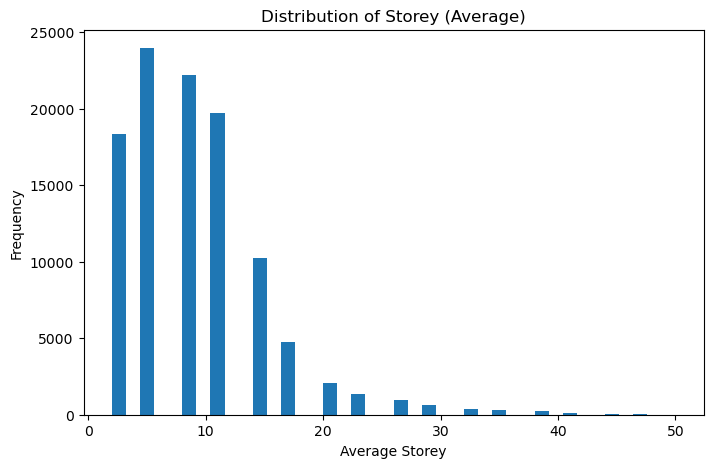

In [110]:
## Understanding distribution of Floor Area
plt.figure(figsize=(8,5))
plt.hist(df['floor_area_sqm'], bins=40)
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Frequency')
plt.title('Distribution of Floor Area')
plt.show()
## Understanding distribution of Remaining Lease
plt.figure(figsize=(8,5))
plt.hist(df['remaining_lease_years'], bins=40)
plt.xlabel('Remaining Lease (Years)')
plt.ylabel('Frequency')
plt.title('Distribution of Remaining Lease')
plt.show()
## Understanding distribution of Storey (Average)
plt.figure(figsize=(8,5))
plt.hist(df['storey_avg'].dropna(), bins=40)
plt.xlabel('Average Storey')
plt.ylabel('Frequency')
plt.title('Distribution of Storey (Average)')
plt.show()



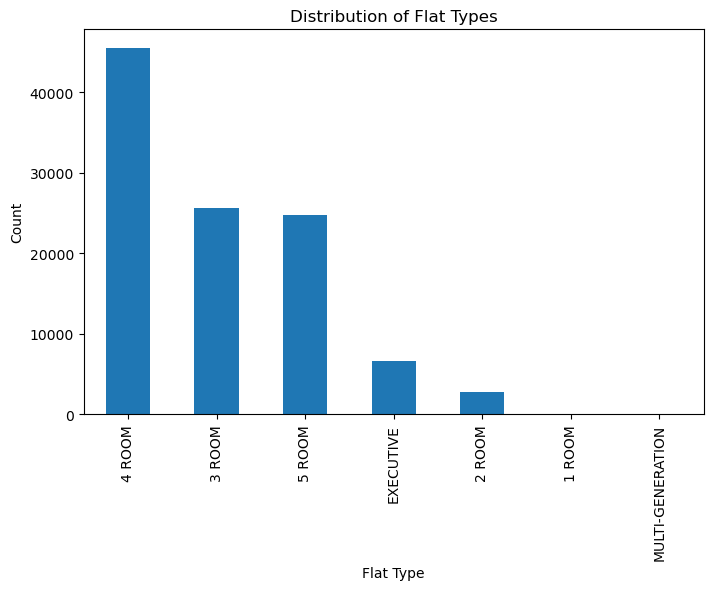

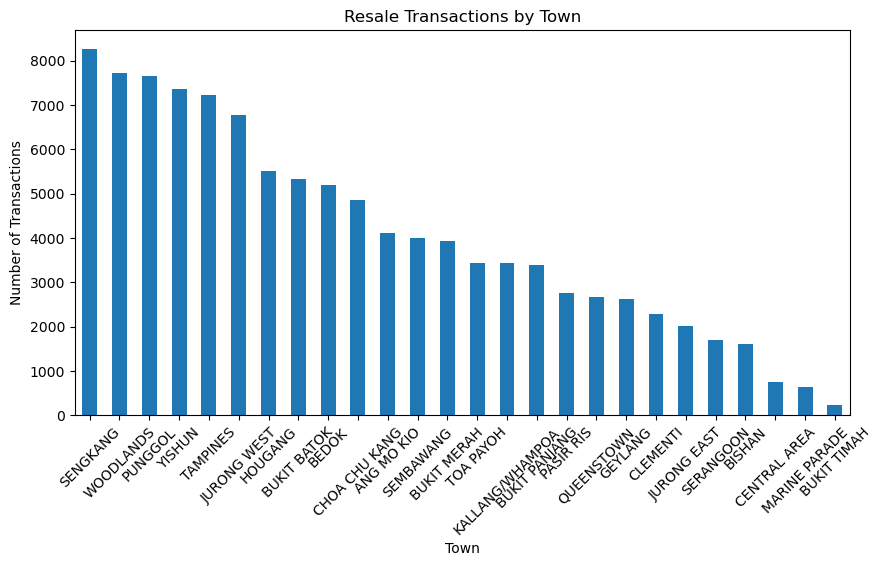

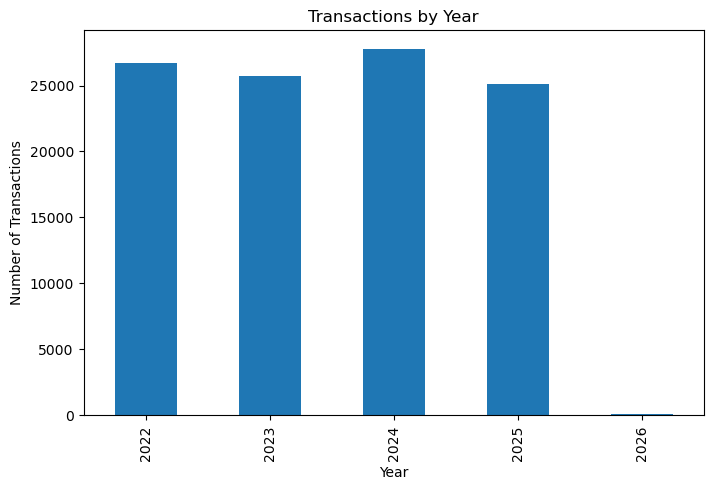

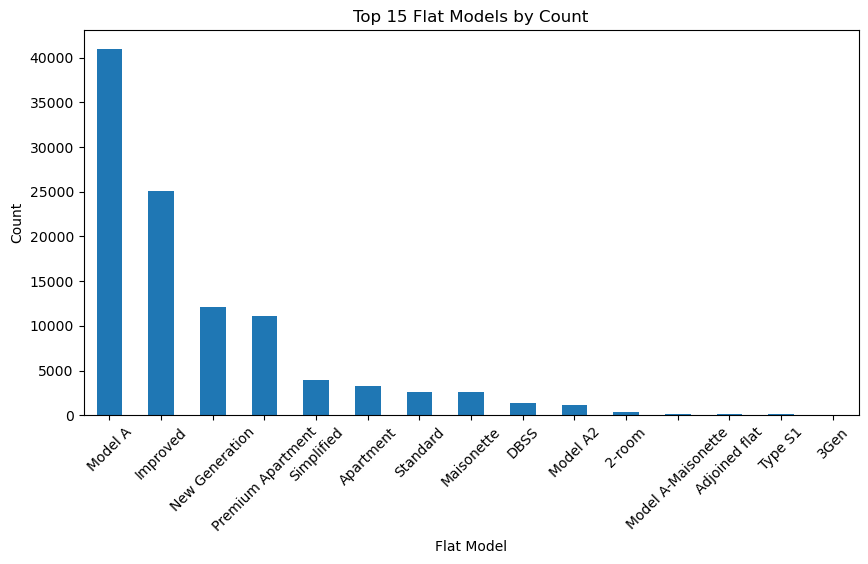

In [111]:
##Understanding distribution of Flat Types
df['flat_type'].value_counts().plot(kind='bar', figsize=(8,5))
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.title('Distribution of Flat Types')
plt.show()
##Understanding distribution of Towns
df['town'].value_counts().plot(kind='bar', figsize=(10,5))
plt.xlabel('Town')
plt.ylabel('Number of Transactions')
plt.title('Resale Transactions by Town')
plt.xticks(rotation=45)
plt.show()
##Understanding distribution of Years
plt.figure(figsize=(8,5))
df['year'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.title('Transactions by Year')
plt.show()
##Understanding distribution of Flat Models
top_n = 15
plt.figure(figsize=(10,5))
df['flat_model'].value_counts().head(top_n).plot(kind='bar')
plt.xlabel('Flat Model')
plt.ylabel('Count')
plt.title(f'Top {top_n} Flat Models by Count')
plt.xticks(rotation=45)
plt.show()


**2.3.1.2 Understanding distribution of features**

1. **Floor area (sqm)**  
The distribution is right‑skewed with most flats within in the mid‑size range (70–120 sqm), and there is a long tail of large flats above 150–200 sqm.  
**Implication:** floor area is most likely a strong driver of resale price, but jumbo large units are rare and may be potential outliers.

2. **Remaining lease (years)**  
The distribution is multimodal, with visible peaks around the 50–60, 70–80, and 90+ year ranges. This reflects different flat age ranges(older resale vs newer BTO).  
**Implication:** remaining lease should have a non‑linear relationship with price;

3. **Storey (average)**  
Most transactions are in low‑to‑mid storeys (roughly under 15), with a long tail up to very high floors.  
**Implication:** higher storey flats are way less common and may act as outliers, as a result the price effect of storey may be diminish after a certain level.

4. **Flat type**  
4‑room flats are the most common, followed by 3‑room and 5‑room. 1‑room and multi‑generation are rare.  
**Implication:** the dataset is imbalanced across flat types; predictions for rare types will be less reliable.

5. **Town**  
Some towns are popular and dominate the transaction count while other towns have relatively few records.  
**Implication:** one‑hot encoding for towns may cause sparsity and overfitting for low‑volume towns, grouping them by NSEW may help.

6. **Year**  
Transaction counts are fairly stable from 2022–2025, while 2026 is much smaller as the year just begun.  
**Implication:** 2026 data may need to be excluded if it biases the model.

7. **Flat model**  
A few flat models (e.g., Model A, Improved, New Generation) are dominant, with a long tail of rare models.  
**Implication:** high‑cardinality categorical data can introduce sparsity, grouping rare models or using simplified categories can improve generalization.


### 2.3.2 Understanding relationship between variables

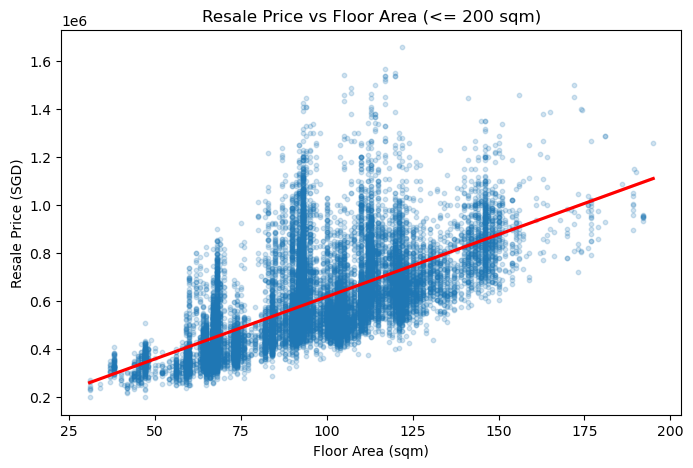

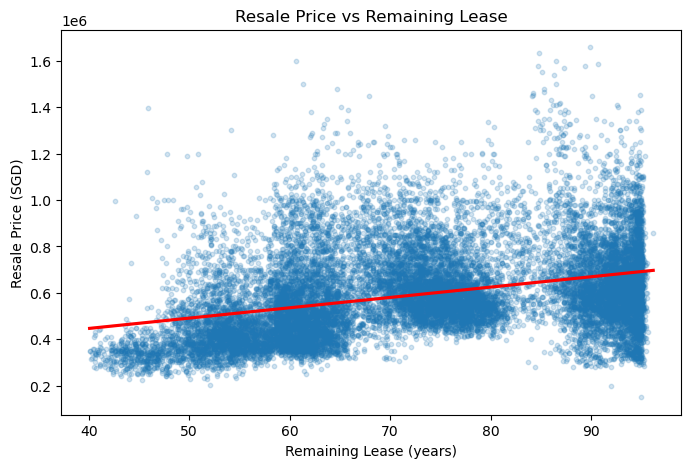

In [112]:
## Understanding relationship between Resale Price and Floor Area
df_zoom = df[df['floor_area_sqm'] <= 200]

plt.figure(figsize=(8,5))
sns.regplot(
    x='floor_area_sqm', y='resale_price',
    data=df_zoom.sample(20000, random_state=42),
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'}
)
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Floor Area (<= 200 sqm)')
plt.show()


## Understanding relationship between Resale Price and Remaining Lease
df_sample = df.sample(20000, random_state=42)

plt.figure(figsize=(8,5))
sns.regplot(
    x='remaining_lease_years', y='resale_price',
    data=df_sample,
    scatter_kws={'alpha':0.2, 's':10},
    line_kws={'color':'red'}
)
plt.xlabel('Remaining Lease (years)')
plt.ylabel('Resale Price (SGD)')
plt.title('Resale Price vs Remaining Lease')
plt.show()


In [113]:
# Understanding the Average resale price by year and flat type
avg_by_year = (
    df.groupby(['year', 'flat_type'])['resale_price']
      .mean()
      .reset_index()
)

order = ["1 ROOM","2 ROOM","3 ROOM","4 ROOM","5 ROOM","EXECUTIVE","MULTI-GENERATION"]

fig = plotly.graph_objects.Figure()
for ft in order:
    sub = avg_by_year[avg_by_year['flat_type'] == ft]
    fig.add_trace(plotly.graph_objects.Scatter(
        x=sub['year'],
        y=sub['resale_price'],
        mode='lines+markers',
        name=ft
    ))

fig.update_layout(
    title="Average Resale Price Trend",
    xaxis_title="Year",
    yaxis_title="Average Resale Price (SGD)",
    legend_title="Flat Type",
    xaxis=dict(dtick=1)
)
fig.update_layout(
    yaxis=dict(dtick=100_000, tickformat=",.0f")
)
fig.show()


In [114]:
## Understanding the Resale Price Distribution by Flat Type
order = ["1 ROOM","2 ROOM","3 ROOM","4 ROOM","5 ROOM","EXECUTIVE","MULTI-GENERATION"]

fig = plotly.graph_objects.Figure()
for ft in order:
    sub = df[df["flat_type"] == ft]
    fig.add_trace(plotly.graph_objects.Histogram(
        x=sub["resale_price"],
        name=ft,
        nbinsx=40
    ))

fig.update_layout(
    title="Resale Prices Distribution by Flat Type",
    xaxis_title="Resale Price (SGD)",
    yaxis_title="Count",
    barmode="stack",
    bargap=0.05,
    legend=dict(title="flat_types:", x=1.02, y=1, xanchor="left")
)
fig.show()

In [115]:
## Understanding the Resale Prices by Town
fig = plotly.graph_objects.Figure()
for t in df['town'].unique():
    fig.add_trace(plotly.graph_objects.Box(
        y=df.loc[df['town'] == t, 'resale_price'],
        name=t,
        boxpoints='outliers'
    ))

fig.update_layout(
    title="Resale Prices by Town",
    xaxis_title="Town",
    yaxis_title="Resale Price (SGD)",
    xaxis_tickangle=-45,
    height=700
)

fig.show()



In [116]:
## Grouping towns into regions for better visualization
north = ['YISHUN','SENGKANG','SEMBAWANG','WOODLANDS','PUNGGOL','HOUGANG']
south = ['QUEENSTOWN','BUKIT MERAH']
east  = ['TAMPINES','PASIR RIS','BEDOK','MARINE PARADE']
west  = ['JURONG WEST','JURONG EAST','CLEMENTI','BUKIT BATOK','BUKIT PANJANG','CHOA CHU KANG']
central = ['ANG MO KIO','TOA PAYOH','SERANGOON','BISHAN','KALLANG/WHAMPOA','GEYLANG','CENTRAL AREA','BUKIT TIMAH']

df_region = df.copy()
df_region['region'] = 'Central'  # default

df_region.loc[df_region['town'].isin(north), 'region'] = 'North'
df_region.loc[df_region['town'].isin(south), 'region'] = 'South'
df_region.loc[df_region['town'].isin(east), 'region'] = 'East'
df_region.loc[df_region['town'].isin(west), 'region'] = 'West'
df_region.loc[df_region['town'].isin(central), 'region'] = 'Central'

# Boxplot by region
fig = plotly.graph_objects.Figure()
for r in ['North', 'South', 'East', 'West', 'Central']:
    sub = df_region[df_region['region'] == r]
    fig.add_trace(plotly.graph_objects.Box(
        y=sub['resale_price'],
        name=r,
        boxpoints='outliers'
    ))

fig.update_layout(
    title="Resale Prices by Region",
    xaxis_title="Region",
    yaxis_title="Resale Price (SGD)"
)

fig.show()




In [117]:
## Impact of Storey Range on Resale Price

# Prepare data for storey bins
df_storey = df[['storey_avg', 'resale_price']].dropna().copy()

# Create storey bins of size 3 (e.g., 01 TO 03, 04 TO 06)
df_storey['bin_start'] = ((df_storey['storey_avg'] - 1) // 3 * 3 + 1).astype(int)
df_storey['storey_bin'] = df_storey['bin_start'].apply(lambda s: f"{s:02d} TO {s+2:02d}")

# Define the order of bins for consistent plotting
order = [f"{s:02d} TO {s+2:02d}" for s in sorted(df_storey['bin_start'].unique())]

fig = plotly.graph_objects.Figure()
for b in order:
    sub = df_storey[df_storey['storey_bin'] == b]
    fig.add_trace(plotly.graph_objects.Box(
        y=sub['resale_price'],
        name=b,
        boxpoints='outliers'
    ))

fig.update_layout(
    title="Impact of Storey Range on Resale Price",
    xaxis_title="Storey Range",
    yaxis_title="Resale Price (SGD)",
    xaxis_tickangle=-45
)

fig.show()



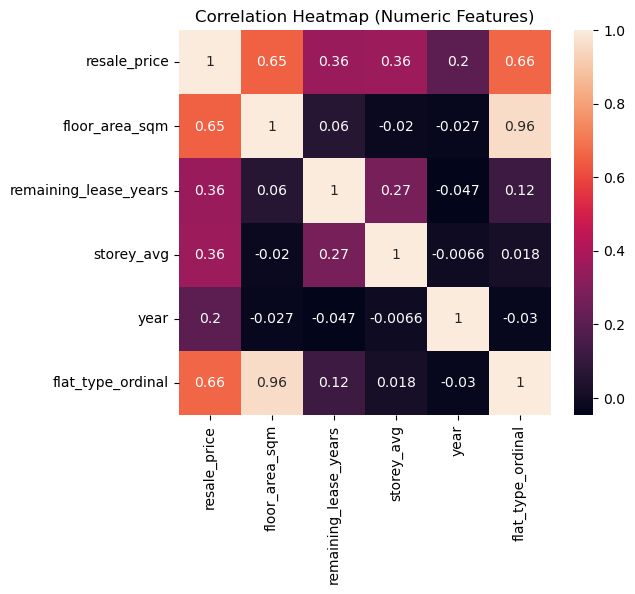

In [118]:
numeric_cols = [
    'resale_price',
    'floor_area_sqm',
    'remaining_lease_years',
    'storey_avg',
    'year',
    'flat_type_ordinal'
]

plt.figure(figsize=(6,5))
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


**2.3.2 Understanding relationship between variables**

1. **Resale price vs floor area**  
From the scatter plot, there is a clear positive relationship where a larger floor area generally leads to higher resale prices. The spread increases for larger flats, and there are high price outliers.  
**Implication:** floor area is a strong predictor; variability grows with size, so errors may be larger for big flats.

2. **Resale price vs remaining lease**  
The trend line shows a positive relationship, but the points are widely scattered.  
**Implication:** remaining lease matters but it is weaker than floor area.

3. **Average resale price trend by year and flat type**  
Prices rise across all flat types from 2022–2025 with the exception of 2026(partial). Larger flat types consistently have higher resale price.  
**Implication:** the year captures the market trend, but may reduce generalization if the market shifts trend differs, can consider to rely only on physical aspects.

4. **Resale prices by flat type (stacked distribution)**  
Larger flat types have higher price ranges, but distributions still overlap.  
**Implication:** flat type is important, but price is not determined by flat type alone.

5. **Resale prices by town (boxplots)**  
There are clear differences in medians and spreads across towns, with some towns consistently having higher resale price and more outliers.  
**Implication:** location is a major factor and town encoding will help but it also adds high‑cardinality sparsity.

6. **Resale prices by region**  
The region level boxplot shows clear differences in medians and spreads, where Central and South generally have higher median prices and wider spreads, and North tends to be lower with a tighter range.  
**Implication:** location remains a strong factor even at a regional level, so grouping towns into regions may be a potential feature engineering instead of OHE.

7. **Impact of storey range on resale price**  
Medians generally increase with higher storey ranges, but there is overlap across ranges.  
**Implication:** storey level has a positive but smaller effect compared to size and location.

8. **Correlation heatmap (numeric features)**  
Resale price correlates most with `floor_area_sqm` (~0.65) and `flat_type_ordinal` (~0.66), while `remaining_lease_years` and `storey_avg` are moderate (~0.36), and `year` is weaker (~0.20). `floor_area_sqm` and `flat_type_ordinal` are highly correlated (~0.96).  
**Implication:** This tells me that size related features are the strongest factors, but multicollinearity exists and removing one of the two size may help linear models.


# 3. Data Preparation

## 3.1 Data Cleaning

In [119]:
df_before = df.copy()


In [120]:
## Clean data
## Perform one-hot encoding on town
df = pd.get_dummies(df, columns=['town'], drop_first=True)

col_y = 'resale_price'
y = df[col_y]

col_ireelevant = ['resale_price', 'flat_type', 'flat_model','year','lease_commence_date']
x = df.drop(col_ireelevant, axis=1)
x

,floor_area_sqm,flat_type_ordinal,storey_avg,remaining_lease_years,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,town_BUKIT TIMAH,...,town_PASIR RIS,town_PUNGGOL,town_QUEENSTOWN,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN
116676,44.0,2,8.0,54.416667,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
116677,67.0,3,2.0,57.166667,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
116678,67.0,3,2.0,56.583333,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
116679,68.0,3,2.0,57.083333,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
116680,68.0,3,2.0,57.000000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222213,92.0,4,5.0,88.916667,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222214,92.0,4,11.0,88.916667,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222215,93.0,4,2.0,94.333333,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
222216,84.0,4,11.0,58.750000,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


## 3.2 Train-Test Split

In [121]:
## Split data into train set and test set
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=2025
)
linr = LinearRegression()
linr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 4. Baseline Model (Linear Regression)

### 4.2 Train Model

In [122]:
## Initialise and train model
y_pred = linr.predict(X_test)


# 5. Model Evaluation

**Evaluation Metrics**

**Primary metric: MAE (Mean Absolute Error)**  
MAE is chosen as the main metric as it reflects the average absolute error in dollars, which is directly meaningful to buyers and sellers when interpreting price estimates.

**Secondary metrics: RMSE and R²**  
RMSE is reported to penalize large errors more heavily, highlighting the risk of big mispricing.  
R² is reported to show how much variance in resale price is explained by the model.

*In summary, MAE is the most business‑relevant, while RMSE and R² provide additional technical insight.*


In [123]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print('Linear RegressionL MAE:', mean_absolute_error(y_test, y_pred))
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Linear Regression RMSE:', root_mean_squared_error(y_test, y_pred))
print('Linear Regression R^2:', r2_score(y_test, y_pred))


Linear RegressionL MAE: 65093.073219780745
Linear Regression MSE: 7189309713.901192
Linear Regression RMSE: 84789.79722762163
Linear Regression R^2: 0.799195892970193


**Linear Regression (Initial)**

| Model | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Linear Regression | 65,093.07 | 84,789.80 | 0.7992 |


In [124]:
## New data
new_data = pd.DataFrame([
    {"town": "ANG MO KIO",  "floor_area_sqm": 67,  "storey_avg": 5,  "lease_commence_date": 1980,  "year": 2022, "flat_type_ord": 3},
    {"town": "BEDOK",       "floor_area_sqm": 92,  "storey_avg": 10, "lease_commence_date": 1978,  "year": 2023, "flat_type_ord": 4},
    {"town": "JURONG WEST", "floor_area_sqm": 110, "storey_avg": 12, "lease_commence_date": 1985,  "year": 2024, "flat_type_ord": 5},
    {"town": "BUKIT MERAH", "floor_area_sqm": 115, "storey_avg": 20, "lease_commence_date": 1955,  "year": 2021, "flat_type_ord": 5},
    {"town": "PUNGGOL",     "floor_area_sqm": 130, "storey_avg": 15, "lease_commence_date": 1990,  "year": 2024, "flat_type_ord": 6},
])

## Predict
new_data_encoded = pd.get_dummies(new_data, columns=['town'], drop_first=True)

## Align columns to training features (x is your training feature dataframe)
new_data_encoded = new_data_encoded.reindex(columns=x.columns, fill_value=0)

## Predict
new_pred = linr.predict(new_data_encoded)

pd.DataFrame({
    "Predicted_Resale_Price": new_pred
})


,Predicted_Resale_Price
0,15204.231721
1,132870.700290
2,95499.616574
3,413723.293503
4,228474.600794


## Iterative Model Development


### 1.1 Feature Selection

**Remaining_lease_years vs Lease_commence_date**

**Initially I thought that having both features was redundant due multicollinearity,  as I found that both of these features were similar in terms of representing the flats age, just that one is the birthdate(lease_commence_date) and the other is the current age(remaining_lease_years). Thus, I chose to drop lease_commence_date and select remaning_lease_years as it is more intuitive and more commonly used term.**

| Feature Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| With `lease_commence_date` | 62,232.64 | 81,313.66 | 0.8153 |
| With `remaining_lease_years` | 65,093.07 | 84,789.80 | 0.7992 |
| With **both included** | **53,269.92** | **70,803.79** | **0.8600** |

**Verdict:**  
I will keep `remaining_lease_years` instead of the other setups(only `lease_commence_date`, `both_included`).

**Explanation:**  
Although the two features are conceptually related, the model performs best when both are included, suggesting each still captures slightly different information (e.g., lease age vs remaining tenure). Since the goal is predictive accuracy, I will keep both whilst noting the multicollinearity risk.

Although the setups consisting of only `lease_commence_date`, `both_included` performed better in terms of MAE, RMSE, and R². Firstly, having `both included` will result in data leakage, where the model may reconstruct the transaction year even though I have already removed it, resulting in it being influenced by the uncontrollable market trend. Secondly, I chose to keep `remaining_lease_years` rather than `lease_commence_date` as using my real world domain logic, buyers/sellers along with the professionals tend to look at how much lease is left at sale raather than the calendar year the lease started, thus it is more realistic and interpretable.

In [125]:
## Drop lease_commence_date from dataset
df = df.drop(columns=['lease_commence_date'])


### 1.2 Feature Engineering: Group Flat Town into Reigons

In [126]:
## Mapping towns to regions
df_before 

town_region_map = {
    #North Region
    'YISHUN': 'North',
    'SENGKANG': 'North',
    'SEMBAWANG': 'North',
    'WOODLANDS': 'North',
    'PUNGGOL': 'North',
    'HOUGANG': 'North',

    #South Region
    'QUEENSTOWN': 'South',
    'BUKIT MERAH': 'South',

    #East Reigon
    'TAMPINES': 'East',
    'PASIR RIS': 'East',
    'BEDOK': 'East',
    'MARINE PARADE': 'East',

    #West Region
    'JURONG WEST': 'West',
    'JURONG EAST': 'West',
    'CLEMENTI': 'West',
    'BUKIT BATOK': 'West',
    'BUKIT PANJANG': 'West',
    'CHOA CHU KANG': 'West',

    #Central Region
    'ANG MO KIO': 'Central',
    'TOA PAYOH': 'Central',
    'SERANGOON': 'Central',
    'BISHAN': 'Central',
    'KALLANG/WHAMPOA': 'Central',
    'GEYLANG': 'Central',
    'CENTRAL AREA': 'Central',
    'BUKIT TIMAH': 'Central'
}

## Apply mapping to create new column reigon
df_before['region'] = df_before['town'].map(town_region_map).fillna('Central')

## Check the distribution of the new flat_model_class column
print(df_before['region'].value_counts())

# 4. Drop the original column (Optional, but recommended to avoid multicollinearity)
df_before = df_before.drop(columns=['town'])

## One-hot encode the new flat_model_class column
df_before = pd.get_dummies(df_before, columns=['region'], drop_first=True)

region
North      40525
West       24630
Central    17875
East       15831
South       6585
Name: count, dtype: int64


In [127]:
col_y = 'resale_price'
y = df_before[col_y]

col_irrelevant = ['resale_price', 'flat_type', 'flat_model','year','lease_commence_date']  
x = df_before.drop(col_irrelevant, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=2025
)
linr = LinearRegression()
linr.fit(X_train, y_train)

## Initialise and train model
y_pred = linr.predict(X_test)


## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print('Linear RegressionL MAE:', mean_absolute_error(y_test, y_pred))
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Linear Regression RMSE:', root_mean_squared_error(y_test, y_pred))
print('Linear Regression R^2:', r2_score(y_test, y_pred))


Linear RegressionL MAE: 71000.87579636286
Linear Regression MSE: 8762501224.826033
Linear Regression RMSE: 93608.23267654417
Linear Regression R^2: 0.7552551908569836


**One-Hot-Encode Town Only vs Group Town by Reigon**

| Feature Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Towns grouped into regions | 71,000.88 | 93,608.23 | 0.7553 |
| Original (one-hot-encode) | **65,093.07** | **84,789.80** | **0.7992** |

**Verdict:**  
I will Keep the original town one‑hot encoding. It gives better predictive performance than grouping towns into regions.

**Explanation:**  
Grouping towns into broad regions reduces detail and removes location‑specific differences, which hurts accuracy (MAE and RMSE increase, R² drops). While regional grouping simplifies the model and reduces sparsity, it sacrifices important location aspects that are valuable for price prediction.



### 1.3 Feature Engineering: Group Flat Model into Sub-categories

In [128]:
# Create the summary table
summary = df.groupby('flat_model')['resale_price'].agg(['count', 'mean'])

# Rename columns for clarity (Optional but good for reports)
summary = summary.rename(columns={'count': 'Frequency', 'mean': 'Avg_Price'})

# Sort it! (Usually you want to see the most common ones first)
summary = summary.sort_values(by='Frequency', ascending=False)

# Display
print(summary)

                        Frequency     Avg_Price
flat_model                                     
Model A                     40997  5.893902e+05
Improved                    25115  6.086864e+05
New Generation              12129  4.405840e+05
Premium Apartment           11143  6.510456e+05
Simplified                   3943  4.707730e+05
Apartment                    3302  8.307690e+05
Standard                     2649  4.786041e+05
Maisonette                   2597  8.990630e+05
DBSS                         1343  8.822412e+05
Model A2                     1130  4.971730e+05
2-room                        351  3.598491e+05
Model A-Maisonette            179  8.770382e+05
Adjoined flat                 160  8.646476e+05
Type S1                       147  1.233452e+06
3Gen                           66  7.515267e+05
Type S2                        63  1.372217e+06
Premium Apartment Loft         45  1.162213e+06
Terrace                        42  9.613629e+05
Multi Generation               25  9.752

**Reasoning:**
I decided to exclude `flat_model` as one of my features in the inidial model as it is has too many categories(22), one-hot-encoding it on top of the already one-hot-encoded `town` would increase the number of features by alot, making the dataset sparse and increase the risk of overfitting(curse of dimensionality). And since flat_model overlaps in meaning with `flat_type `where both of them describes the flat design/size, I prioritized `flat_type` and left `flat_model` out in the baseline model.

However, as I wanted to capture the effects of the different layout of each `flat_model`, I decided to group `flat_model`'s into broader categories (Standard, Premium, Others). This keeps the feature compact while introducing additional information that may improve accuracy.

In [129]:
## Classify flat_model into categoris: "standard", "premium", and "others"

## Mapping flat_model to categories
model_mapping = {
    # Standard Category
    'Model A': 'Standard',
    'Improved': 'Standard',
    'New Generation': 'Standard',
    'Simplified': 'Standard',
    'Apartment': 'Standard',
    'Standard': 'Standard',
    'Model A2': 'Standard',
    '2-room': 'Standard',
    
    # Premium Category
    'Premium Apartment': 'Premium',
    'DBSS': 'Premium',
    'Type S1': 'Premium',
    'Type S2': 'Premium',
    'Premium Apartment Loft': 'Premium',
    
    # Othersial Category
    'Maisonette': 'others', 
    'Model A-Maisonette': 'others',
    'Adjoined flat': 'others',
    'Terrace': 'others',
    'Multi Generation': 'others',
    '3Gen': 'others',
    'Improved-Maisonette': 'others',
    'Premium Maisonette': 'others'
}

## Apply mapping to create new column flat_model_class
df['flat_model_class'] = df['flat_model'].map(model_mapping).fillna('Standard')

## Check the distribution of the new flat_model_class column
print(df['flat_model_class'].value_counts())

# 4. Drop the original column 
df = df.drop(columns=['flat_model'])

## One-hot encode the new flat_model_class column
df = pd.get_dummies(df, columns=['flat_model_class'], drop_first=False)

flat_model_class
Standard    89616
Premium     12741
others       3089
Name: count, dtype: int64


In [130]:
col_y = 'resale_price'
y = df[col_y]

col_irrelevant = ['resale_price', 'flat_type','year']  
x = df.drop(col_irrelevant, axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=2025
)
linr = LinearRegression()
linr.fit(X_train, y_train)

## Initialise and train model
y_pred = linr.predict(X_test)


## Evaluate model
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print('Linear RegressionL MAE:', mean_absolute_error(y_test, y_pred))
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred))
print('Linear Regression RMSE:', root_mean_squared_error(y_test, y_pred))
print('Linear Regression R^2:', r2_score(y_test, y_pred))



Linear RegressionL MAE: 64238.03555660803
Linear Regression MSE: 6946835623.920635
Linear Regression RMSE: 83347.67917537138
Linear Regression R^2: 0.8059684198265983


**Flat Model Feature Engineering vs Original**

| Feature Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Previous best model | 65,093.07 | 84,789.80 | 0.7992 |
| flat_model grouped (New Best) | **64,238.04** | **83,347.68** | **0.8060** |

**Verdict:**
I will keep the `flat_model` feature (Standard/Premium/Others).

**Explanation:**
After grouping the `flat_model`'s, the MAE, RMSE, and R² had a small improvement compared to the original model, whilst reducing the high cardinality and capturing the degisn effect. 

# 5. Second Model (Decision Tree Regressor)

I picked this as the second model as...

In [131]:
df = df.drop(columns=['year','flat_type'])
df

,floor_area_sqm,resale_price,flat_type_ordinal,storey_avg,remaining_lease_years,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,town_BUKIT PANJANG,...,town_SEMBAWANG,town_SENGKANG,town_SERANGOON,town_TAMPINES,town_TOA PAYOH,town_WOODLANDS,town_YISHUN,flat_model_class_Premium,flat_model_class_Standard,flat_model_class_others
116676,44.0,245000.0,2,8.0,54.416667,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
116677,67.0,300000.0,3,2.0,57.166667,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
116678,67.0,315000.0,3,2.0,56.583333,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
116679,68.0,318000.0,3,2.0,57.083333,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
116680,68.0,320000.0,3,2.0,57.000000,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222213,92.0,585000.0,4,5.0,88.916667,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
222214,92.0,620888.0,4,11.0,88.916667,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
222215,93.0,575000.0,4,2.0,94.333333,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
222216,84.0,490000.0,4,11.0,58.750000,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [132]:
col_y = 'resale_price'
y = df[col_y]
 
col_irrelevant = ['resale_price']  
x = df.drop(col_irrelevant, axis=1)
 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
 
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test =  train_test_split(x, y, test_size=test_size, random_state=random_state)
 
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
 


In [134]:

print('Decision Tree Regressor MAE:', mean_absolute_error(y_test, y_pred_dt))
print('Decision Tree Regressor MSE:', mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor RMSE:', root_mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor R^2:', r2_score(y_test, y_pred_dt))

Decision Tree Regressor MAE: 44044.95820569772
Decision Tree Regressor MSE: 4304449448.662032
Decision Tree Regressor RMSE: 65608.30319907711
Decision Tree Regressor R^2: 0.8797727233642165


**Decision Tree Regressor (All Features)**

| Model | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Decision Tree Regressor | 44,044.96 | 65,608.30 | 0.8780 |


In [135]:
df_dt_feat_impt = pd.DataFrame({
    'Feature': dt.feature_names_in_,
    'Importance': dt.feature_importances_
})

def group_feature(f):
    if f.startswith('town_'):
        return 'town'
    if f.startswith('flat_model_class_'):
        return 'flat_model_class'
    return f  # keep full name for other features

df_dt_feat_impt['FeatureGroup'] = df_dt_feat_impt['Feature'].apply(group_feature)

df_grouped = (df_dt_feat_impt
              .groupby('FeatureGroup', as_index=False)['Importance']
              .sum()
              .sort_values('Importance', ascending=False))

df_grouped


,FeatureGroup,Importance
2,floor_area_sqm,0.500847
5,town,0.208068
3,remaining_lease_years,0.145243
4,storey_avg,0.107582
1,flat_type_ordinal,0.031002
0,flat_model_class,0.007258


## Feature Importance 

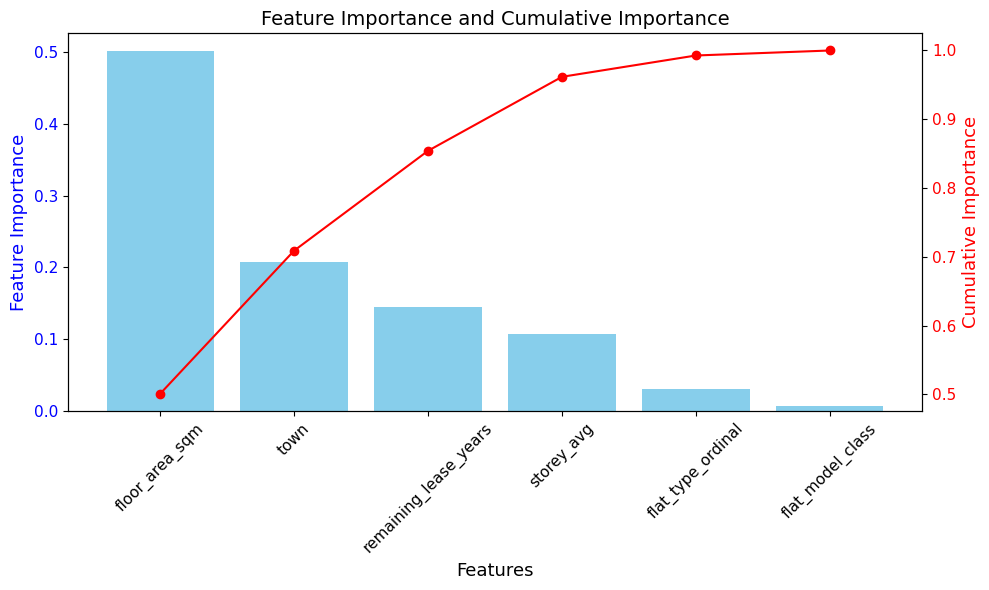

In [136]:
# Aggregate + cumulative importance
df_plot = (
    df_dt_feat_impt
    .groupby('FeatureGroup', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
)
df_plot['Cumulative Importance'] = df_plot['Importance'].cumsum()

## Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for feature importance
ax1.bar(df_plot['FeatureGroup'], df_plot['Importance'], color='skyblue')
ax1.set_xlabel('Features', size=13)
ax1.set_ylabel('Feature Importance', color='blue', size=13)
ax1.tick_params(axis='y', labelcolor='blue', labelsize=11)
ax1.tick_params(axis='x', labelsize=11, rotation=45)

# Line chart for cumulative importance
ax2 = ax1.twinx()
ax2.plot(df_plot['FeatureGroup'], df_plot['Cumulative Importance'], color='red', marker='o')
ax2.set_ylabel('Cumulative Importance', color='red', size=13)
ax2.tick_params(axis='y', labelcolor='red', labelsize=11)

plt.title('Feature Importance and Cumulative Importance', size=14)
plt.tight_layout()
plt.show()

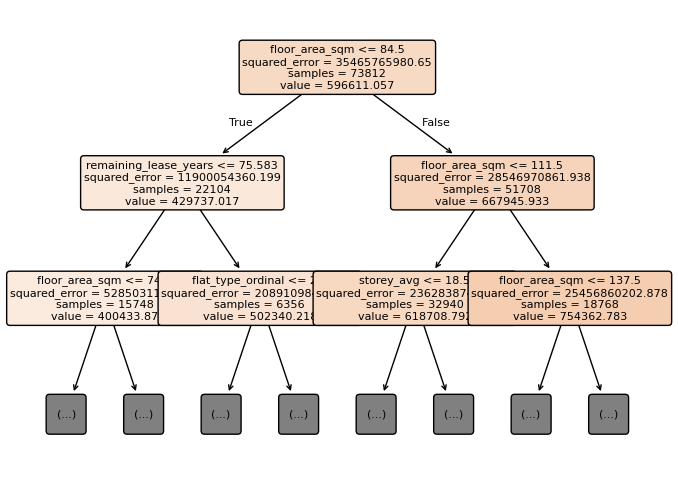

In [137]:
from sklearn.tree import plot_tree

plt.figure(figsize=(8, 6))
plot_tree(dt, 
          feature_names=dt.feature_names_in_, 
          max_depth=2, 
          filled=True, 
          rounded=True,
          fontsize=8
          ) ## max_depth 3 to look at the top level instead of whole tree
plt.show()
 

### Feature Selection

**(1) Feature Importance and Cumulative Importance Graph**
- `floor_area_sqm` is the most influential predictor (~0.50), followed by `town`(~0.21). This tells me that size and location are the strongest factors of resale price in the model.  
- `remaining_lease_years`(~0.14) and `storey_avg`(~0.11) are the next tier of features which are still meaningful, though of less importance.
- `flat_type_ordinal`(~0.03) has low importance, and `flat_model_class`(~0.01) is the least important compared to the top features.  
- The cumulative curve shows that most predictive power is captured by the top few features (top 4).

**(2) Plot Tree Graph**
- The root split is on `floor_area_sqm`, confirming it has the strongest influence on resale_price.  
- Early splits utilize `remaining_lease_years` and `storey_avg`, meaning these features add useful segmentation after floor_area.  
- The tree prioritizes size first, then lease and floor-level effects.

**Plan for Feature Selection (Iterations)**
1. Keep core features: `floor_area_sqm`, `town`, `remaining_lease_years`, `storey_avg`.  
2. Test lower impact features (`flat_type_ordinal`).  
3. Choose the simplest feature set that maintains near best performance.

### Step 1: Keep core features only: `floor_area_sqm`, `town`, `remaining_lease_years`, `storey_avg`.

In [139]:
col_y = 'resale_price'
y = df[col_y]
 
col_irrelevant = ['resale_price','flat_model_class_Standard','flat_model_class_others','flat_model_class_Premium','flat_type_ordinal']  
x = df.drop(col_irrelevant, axis=1)
 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
 
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test =  train_test_split(x, y, test_size=test_size, random_state=random_state)
 
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
 

In [140]:
print('Decision Tree Regressor MAE:', mean_absolute_error(y_test, y_pred_dt))
print('Decision Tree Regressor MSE:', mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor RMSE:', root_mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor R^2:', r2_score(y_test, y_pred_dt))

Decision Tree Regressor MAE: 46444.075939311464
Decision Tree Regressor MSE: 4746718401.615183
Decision Tree Regressor RMSE: 68896.43243024404
Decision Tree Regressor R^2: 0.8674197401573526


**Decision Tree Regressor Comparison 1**

| Model Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Current Best(All) | **44,044.96** | **65,608.30** | **0.8780** |
| Decision Tree 1 | 46,444.08 | 68,896.43 | 0.8674 |

**Verdict:**
The updated Decision Tree performed worser than the original baseline (higher MAE/RMSE and lower R²), so this feature selection setup is not retained.

**Explanation and Next Step:**  
The reduced feature set likely removed useful predictive information. I will continue the feature selection by reintroducing other important features and testing additional features to recover performance while maintaining model simplicity.


### Step 2: Include `flat_type_ordinal` only if it improves metrics.  

In [141]:
col_y = 'resale_price'
y = df[col_y]
 
col_irrelevant = ['resale_price','flat_model_class_Standard','flat_model_class_others','flat_model_class_Premium']  
x = df.drop(col_irrelevant, axis=1)
 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
 
test_size = 0.3
random_state = 2025
X_train, X_test, y_train, y_test =  train_test_split(x, y, test_size=test_size, random_state=random_state)
 
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [142]:
print('Decision Tree Regressor MAE:', mean_absolute_error(y_test, y_pred_dt))
print('Decision Tree Regressor MSE:', mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor RMSE:', root_mean_squared_error(y_test, y_pred_dt))
print('Decision Tree Regressor R^2:', r2_score(y_test, y_pred_dt))

Decision Tree Regressor MAE: 46120.601422652166
Decision Tree Regressor MSE: 4672186751.966385
Decision Tree Regressor RMSE: 68353.39605291301
Decision Tree Regressor R^2: 0.8695014784533459


**Decision Tree Regressor Comparison 2**

| Model Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Current best(All) | **44,044.96** | **65,608.30** | **0.8780** |
| Decision Tree 2 | 46,120.60 | 68,353.40 | 0.8695 |

**Verdict:**  
The Decision Tree improved compared to Step 1 after adding `flat_type_ordinal`, but it is still slightly worse than the current best model (higher MAE/RMSE and lower R²). I will proceed to the next iteration.

**Explanation:**  
Adding `flat_type_ordinal` recovered part of the lost predictive power, which indicates that the lease information is useful. However, the current feature set is still not optimal, so further feature selection is needed to surpass/meet the baseline.


### Step 3: Choose the simplest feature set that maintains near best performance.

**Decision Tree Regressor Comparison between all Iterations**

| Model Setup | MAE (SGD) | RMSE (SGD) | R² |
|---|---:|---:|---:|
| Current Best **(Chosen)** | **44,044.96** | **65,608.30** | **0.8780** |
| Decision Tree 1 | 46,444.08 | 68,896.43 | 0.8674 |
| Decision Tree 2 | 46,120.60 | 68,353.40 | 0.8695 |


**Verdict:**  
I will use the **Current Best (All features)** setup, including `floor_area_sqm`, `town`, `remaining_lease_years`, `storey_avg`, `flat_type_ordinal`, and `flat_model_class` features.

**Explanation:**  
Although `flat_model_class` has relatively low feature importance, including it still gives a consistent overall performance gain (lower MAE/RMSE and higher R²) compared to Decision Tree 2. The improvement is small but meaningful, and the added complexity is minimal as it adds only 3 dummy columns, so retaining the feature is justified.

# 6. Third Model (Random Forest Regression)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor , RandomForestRegressor

gbt = GradientBoostingRegressor()
rf = RandomForestRegressor()
gbt.fit(X_train, y_train)
rf.fit(X_train, y_train)


y_pred_gbt = gbt.predict(X_test)
mean_absolute_error(y_test, y_pred_gbt)
mean_squared_error(y_test, y_pred_gbt)
root_mean_squared_error(y_test, y_pred_gbt)


In [ ]:
y_pred_rf = rf.predict(X_test)
mean_absolute_error(y_test, y_pred_rf)
mean_squared_error(y_test, y_pred_rf)
root_mean_squared_error(y_test, y_pred_rf)

## Define parameter grid
param_grid_rf = {
    'n_estimators': [10, 50], ## Number of trees in the forest
    'criterion': ['squared_error', 'absolute_error'], ## Measure quality of a split
    'max_depth': [1, 2, 3], ## Maximum depth of tree
    'min_samples_split': [2, 5], ## Minimum number of samples required to split a node
    'max_features': ['sqrt', 'log2'] ## Number of features to consider at each split
    }
 
## Initialise model
from sklearn.model_selection import GridSearchCV
gs_rf = GridSearchCV(estimator = rf,
                     param_grid = param_grid_rf,
                     cv = 5, ## Number of cross-validation folds
                     scoring = 'neg_mean_squared_error', ## Scoring metric
                     )
 
gs_rf.fit(X_train, y_train)
 
## Obtain best parameters and best estimator
best_gs_params = gs_rf.best_params_
best_gs_rf = gs_rf.best_estimator_
print("Best Parameters: ", best_gs_params)
print("Best Estimator: ", best_gs_rf)
 
# Save model
import joblib
joblib.dump(best_gs_rf, 'hdb_best_gs_rf_model.pkl') ## Save Random Forest model